# Step 8: Model Evaluation

Final evaluation of the Adam-trained ResNet1D on the held-out test set.

Metrics:
- Overall accuracy + macro/weighted F1
- Per-class precision, recall, F1
- 5x5 normalized confusion matrix
- One-vs-rest ROC-AUC per class
- Full evaluation report

In [1]:
import sys, os
from pathlib import Path
_r = Path.cwd()
while not (_r / 'src').is_dir():
    _r = _r.parent
os.chdir(_r)
if str(_r) not in sys.path:
    sys.path.insert(0, str(_r))

from src.evaluation.metrics import compute_metrics, get_predictions
from src.evaluation.confusion_matrix import plot_confusion_matrix
from src.evaluation.roc_curves import plot_roc_curves
from src.evaluation.report import generate_report
from src.utils.io import load_artifact
from src.utils.device import get_device

In [2]:
from src.data.loader import load_mitbih
from src.data.preprocessor import preprocess
from src.data.dataset import build_dataloaders

X_train_raw, y_train_raw, X_test_raw, y_test_raw = load_mitbih()
splits = preprocess(X_train_raw, y_train_raw, X_test_raw, y_test_raw, val_fraction=0.15)
train_loader, val_loader, test_loader = build_dataloaders(splits, batch_size=128)
print(f'Data ready — test: {splits["X_test"].shape}')

Data ready — test: (21892, 187, 1)


In [3]:
from src.models.resnet1d import ResNet1D

device = get_device()
model = ResNet1D()
model.load_state_dict(load_artifact('results/checkpoints/resnet1d_adam_best.pth'))
model = model.to(device)
model.eval()
y_true, y_pred, y_prob = get_predictions(model, test_loader, device)
metrics = compute_metrics(y_true, y_pred, y_prob)
print(f'Accuracy: {metrics.accuracy:.4f}')
print(f'Macro F1: {metrics.macro_f1:.4f}')

Using GPU: NVIDIA GeForce RTX 4070 Laptop GPU
Accuracy: 0.9820
Macro F1: 0.9140


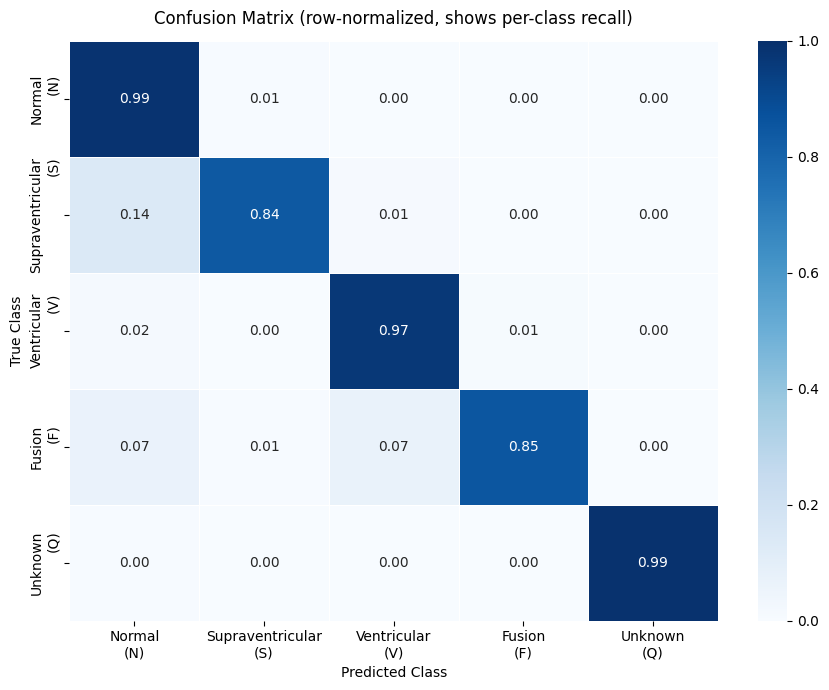

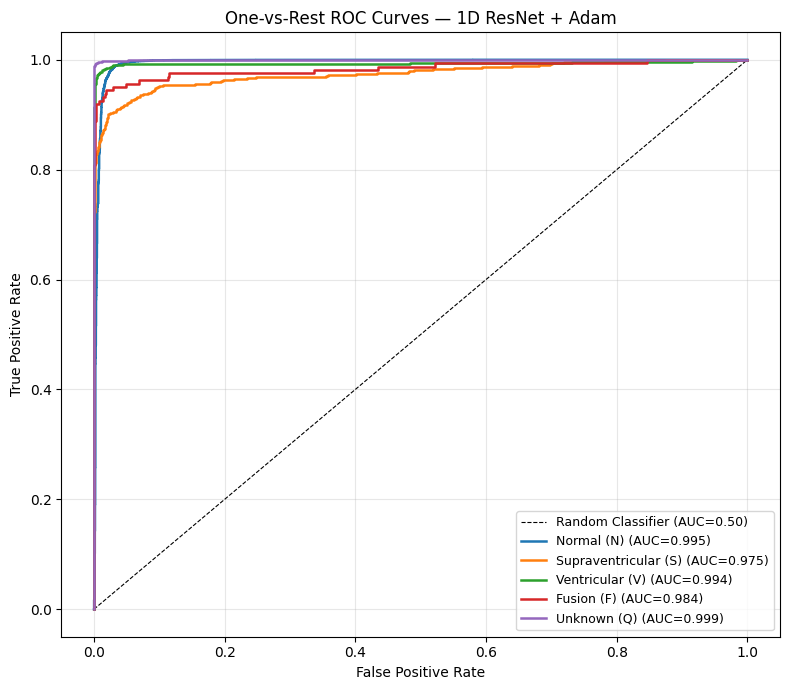

CardioSense — Model Evaluation Report
1D ResNet + Adam Optimizer (Kingma & Ba, ICLR 2015)

── Overall Metrics ──────────────────────────────────────────
  Accuracy      : 0.9820  (target ≥ 0.98)
  Macro F1      : 0.9140  (target ≥ 0.93)
  Weighted F1   : 0.9823
  Mean ROC-AUC  : 0.9892

── Per-Class Metrics ────────────────────────────────────────
                      Precision  Recall      F1  ROC-AUC
Class                                                   
Normal (N)               0.9931  0.9879  0.9905   0.9946
Supraventricular (S)     0.7774  0.8417  0.8083   0.9748
Ventricular (V)          0.9447  0.9675  0.9560   0.9936
Fusion (F)               0.8023  0.8519  0.8263   0.9837
Unknown (Q)              0.9876  0.9907  0.9891   0.9991

── References ───────────────────────────────────────────────
  Kingma & Ba (2015). Adam: A Method for Stochastic Optimization.
  Lin et al. (2017). Focal Loss for Dense Object Detection.
  He et al. (2016). Deep Residual Learning for Image Recogniti

In [4]:
plot_confusion_matrix(y_true, y_pred, save_path='results/plots/confusion_matrices/confusion_matrix.png')
plot_roc_curves(y_true, y_prob, save_path='results/plots/roc_curves/roc_all_classes.png')
df = generate_report(metrics)